In [1]:
pip install networkx matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [22]:
!pip install pyvis

   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ------------- -------------------------- 262.1/756.0 kB ? eta -:--:--
   ---------------------------------------- 756.0/756.0 kB 6.3 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [pyvis]
   ---------------------------------------- 2/2 [pyvis]



# Transportation topology

Graph created with 49 nodes and 62 edges.


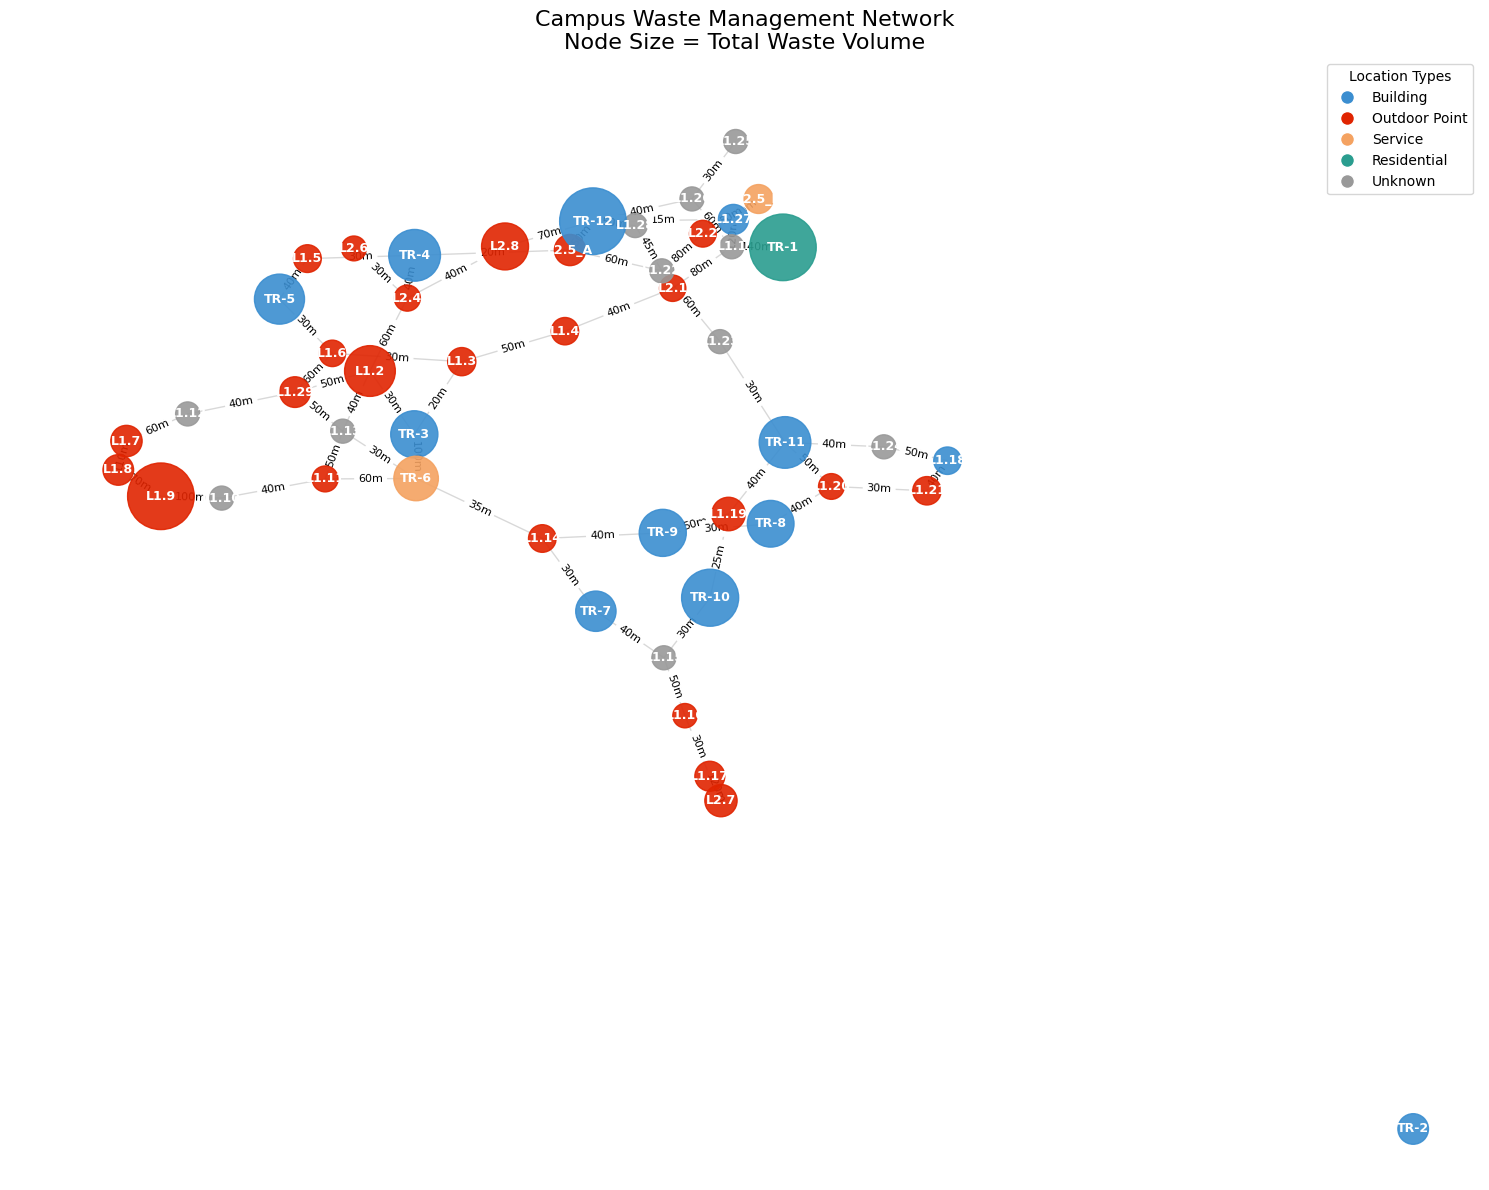

In [5]:
import json
import csv
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# --- Configuration ---
OUTDOOR_FILE = './data/outdoor_trashbuffer.json'
BUILDING_FILE = './data/building_trashbuffer.json'
EDGES_FILE = './data/extracted_adjacent_travesal_path.csv'

def load_nodes(json_files):
    """Reads multiple JSON files and combines their node data."""
    combined_nodes = {}
    
    for file_path in json_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                for node in data.get('nodes', []):
                    # Store key details: ID, Name, Type, and Total Waste
                    node_id = node['id']
                    combined_nodes[node_id] = {
                        'name': node.get('name_en', node_id),
                        'type': node.get('type', 'Unknown'),
                        'waste_total': node.get('waste', {}).get('total', 0)
                    }
        except FileNotFoundError:
            print(f"Warning: File {file_path} not found.")
            
    return combined_nodes

def create_waste_graph(nodes_data, edges_file):
    """Constructs a NetworkX graph from node dictionary and edges CSV."""
    G = nx.Graph()

    # 1. Add Nodes
    for node_id, attributes in nodes_data.items():
        G.add_node(node_id, **attributes)

    # 2. Add Edges from CSV
    try:
        edges_df = pd.read_csv(edges_file)
        for _, row in edges_df.iterrows():
            source, target = row['Source'], row['Target']
            weight = row['Weight']
            
            # Only add edge if both nodes exist in our JSON data
            # (Optional: Remove this check if you want to include nodes mentioned only in CSV)
            if source in nodes_data and target in nodes_data:
                G.add_edge(source, target, weight=weight)
            elif source in nodes_data or target in nodes_data:
                # Add the edge anyway to ensure connectivity, even if one node is a "waypoint"
                G.add_edge(source, target, weight=weight)
                
    except FileNotFoundError:
        print(f"Error: {edges_file} not found.")

    return G

def visualize_graph(G):
    """Draws the graph with color-coding and dynamic sizing."""
    plt.figure(figsize=(15, 12))

    # --- Layout ---
    # spring_layout uses the 'weight' (distance) to pull connected nodes closer
    pos = nx.spring_layout(G, weight='weight', seed=42, k=0.3, iterations=50)

    # --- Node Styling ---
    # Define colors for different node types
    color_map = []
    size_map = []
    
    type_colors = {
        'Building': '#3b8ed0',    # Blue
        'Outdoor Point': '#e02401', # Red
        'Service': '#f4a261',       # Orange
        'Residential': '#2a9d8f',   # Teal
        'Unknown': '#999999'        # Grey
    }

    for node in G.nodes():
        node_type = G.nodes[node].get('type', 'Unknown')
        waste_amt = G.nodes[node].get('waste_total', 0)
        
        # Color based on type
        color_map.append(type_colors.get(node_type, '#999999'))
        
        # Size based on waste amount (Base size 300 + scaled waste)
        # We limit the max size to prevent giant nodes covering the map
        size_map.append(300 + min(waste_amt * 0.5, 2000))

    # --- Drawing ---
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
    
    # Draw Edge Labels (Distances)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    # Simplifies labels to just integers
    edge_labels = {k: f"{int(v)}m" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=size_map, alpha=0.9)

    # Draw Node Labels (ID)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", font_color="white")

    # --- Legend & Title ---
    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=k,
                              markerfacecolor=v, markersize=10) for k, v in type_colors.items()]
    
    plt.legend(handles=legend_elements, loc='upper right', title="Location Types")
    plt.title("Campus Waste Management Network\nNode Size = Total Waste Volume", fontsize=16)
    plt.axis('off') # Turn off the axis numbers
    plt.tight_layout()
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    # 1. Load Data
    all_nodes = load_nodes([OUTDOOR_FILE, BUILDING_FILE])
    
    # 2. Build Graph
    graph = create_waste_graph(all_nodes, EDGES_FILE)
    
    # 3. Visualize
    print(f"Graph created with {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges.")
    visualize_graph(graph)

# Code generation

In [2]:
import json 
extracted_data_path = "../Causal_extractor/data_extract/output/transcript/V5/chuck/raw_gemini_chunk/response_raw_gemini_combined.json"
extracted_data_path = "../Causal_extractor/data_extract/output/transcript/V6/response_raw_gemini_chunk_1.json"
data = json.load(open(extracted_data_path, 'r', encoding='utf-8'))

In [3]:
data

[{'pattern_type': 'A',
  'sentence_type': 'SB',
  'marked_type': 'N/A',
  'explicit_type': 'E',
  'marker': 'null',
  'source_text': 'ส่วนสถานที่อยู่ในภาพรวมที่มารวมอยู่ที่โรงคัดแยกขยะเนี่ย ก็จะถูกส่งให้กับ กทม. ก็คือส่ง กทม. กำจัดนั่นแหละ',
  'extracted': [{'head': 'General waste gathered at the sorting facility',
    'relationship': 'is sent to',
    'tail': 'BMA (Bangkok Metropolitan Administration)',
    'detail': 'for disposal'}]},
 {'pattern_type': 'A',
  'sentence_type': 'SB',
  'marked_type': 'N/A',
  'explicit_type': 'E',
  'marker': 'null',
  'source_text': 'เขาก็จะเอาขยะจากหน่วยงาน หรือสำนักงานของตัวเองเนี่ยลงมาไว้ตามแต่ละตึก... ทางร้านรับซื้อของเก่า... ก็จะมา... เพื่อจดบันทึกว่าหน่วยงานนี้มีอะไรบ้าง ได้เท่าไหร่ๆ น้ำหนักเท่าไหร่',
  'extracted': [{'head': 'Department staff',
    'relationship': 'bring down',
    'tail': 'waste',
    'detail': 'to designated spots at each building on the last Thursday of the month'},
   {'head': 'Contracted scrap buying shop and central manag

In [4]:
import pandas as pd
df = pd.DataFrame(data)
df["n_entity"] = df['extracted'].apply(len)

In [5]:
len(df)

9

<Axes: xlabel='n_entity'>

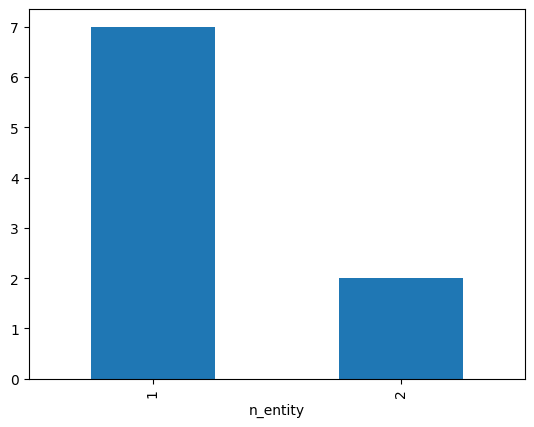

In [6]:
df["n_entity"].value_counts().plot.bar()

note from this structure may be extract them into hyper-relational form  

In [17]:
df[df["n_entity"] == 3]

,pattern_type,sentence_type,marked_type,explicit_type,relationship,marker,entities,source_text,n_entity
9,F,D,N/A,E,Waste generated is categorized into internal a...,null,"[Waste generated, Internal waste, External waste]",โดยขยะที่เกิดขึ้นเนี่ย ตาม... เกิดขึ้นประจำทุก...,3
11,A,SB,N/A,E,Housekeepers weigh waste and place it in holdi...,null,"[Housekeepers, Waste weighing, Holding cages]",เขาก็จะเก็บรวบรวมแต่ละถัง ชั่งน้ำหนัก แล้วก็เอ...,3
12,A,SB,N/A,E,The gardening team drives to collect external ...,null,"[Gardening team, External waste, Vehicle colle...",ก็จะเป็นทีมของงานสวน ที่ดูแลสวนภายนอกเนี่ย เขา...,3
13,F,SB,N/A,E,Staff inconsistently record waste data despite...,null,"[Staff, Data recording, Inconsistency]",เขาก็จะมีการจดบันทึก จดบ้าง ไม่จดบ้าง แต่ก็จะพ...,3
16,C,OT,M,I,High waste volume combined with insufficient s...,จาก,"[High waste volume, Insufficient staff (3-4 pe...",จากปริมาณขยะเป็นหมื่น ... จากคน 3 คนในการคัดแย...,3
42,A,SB,N/A,E,Staff weigh waste under the building and recor...,null,"[Staff, Weighing scale under building, Noteboo...",แต่ละตึก ใต้ตึกเนี่ย จะมีกิโล ... ก็คือจะมาชั่...,3
43,F,ES,N/A,E,Waste collectors often lift bins onto the truc...,null,"[Waste collectors, Waste bins, Truck]",เขาก็ ส่วนใหญ่ก็ ยกขึ้นรถเลย ไม่ต้องชั่ง ไม่ค่...,3
44,C,SP,M,E,Using new equipment helps increase convenience...,ช่วยให้,"[New equipment/tool, Convenience, Immediate da...",อยากได้ อุปกรณ์ หรือ เครื่องมือ ที่มัน ช่วย ให...,3


may be use multiple triple can help
ex. (h r t)
- (Housekeeper, collect, waste)
- (Housekeeper, sort, waste, partially)
- (Staff, discard, waste)
- (Student, discard, waste)

In [18]:
df[df["n_entity"] == 4]

,pattern_type,sentence_type,marked_type,explicit_type,relationship,marker,entities,source_text,n_entity
10,A,SB,N/A,E,Housekeepers collect and partially sort waste ...,null,"[Housekeepers, Waste collection, Partial sorti...",แม่บ้านที่จะคอยดูแล ก็คือจะมาคอยเก็บ ช่วยคัดแย...,4


In [7]:
import matplotlib.pyplot as plt

def plot_graph_visual(G):
    plt.figure(figsize=(10, 6))
    
    # 1. Define layout (Spring layout separates nodes naturally)
    pos = nx.spring_layout(G, seed=42)
    
    # 2. Separate nodes by type for coloring
    event_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'CausalEvent']
    entity_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'Entity']
    
    # 3. Draw Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=event_nodes, node_color='red', node_size=1500, label="Events")
    nx.draw_networkx_nodes(G, pos, nodelist=entity_nodes, node_color='skyblue', node_size=1000, label="Entities")
    
    # 4. Draw Edges with Labels (showing 'HAS_CAUSE', 'HAS_EFFECT')
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
    edge_labels = nx.get_edge_attributes(G, 'role')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
    
    # 5. Draw Labels (Names)
    # For events, we might want a shorter label than the unique ID
    labels = {n: (attr['label'] if 'label' in attr else 'EVENT') for n, attr in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels, font_size=10)
    
    plt.title("Reified Graph Structure")
    plt.legend()
    plt.axis('off')
    plt.show()

# Run it


# retriever model
this is still needed for detect existing node due to named reference inconsistence
- distilated qwen2-0.5B
- paper: https://arxiv.org/pdf/2506.20923
- huggingface: https://huggingface.co/KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5

In [7]:
from sentence_transformers import SentenceTransformer
import torch

model = SentenceTransformer(
    "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5",
    trust_remote_code=True,
    model_kwargs={
        "torch_dtype": torch.bfloat16,
        # "attn_implementation": "flash_attention_2",  # Optional
    },
)
model.max_seq_length = 512

sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(
    sentences,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
)
print(embeddings)
'''
[[-0.01043701 -0.02172852  0.0100708  ... -0.02807617  0.00157166
  -0.03637695]
 [-0.00424194  0.02966309  0.03686523 ... -0.02587891  0.01953125
  -0.00125122]]
'''


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\conda\envs\localcomputer\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bestk\.cache\huggingface\hub\models--KaLM-Embedding--KaLM-embedding-multilingual-mini-instruct-v2.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/55.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/370 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[[-0.01025391 -0.02087402  0.00982666 ... -0.02734375  0.0011673
  -0.03588867]
 [-0.00415039  0.02990723  0.03637695 ... -0.02624512  0.01965332
  -0.00141907]]


'\n[[-0.01043701 -0.02172852  0.0100708  ... -0.02807617  0.00157166\n  -0.03637695]\n [-0.00424194  0.02966309  0.03686523 ... -0.02587891  0.01953125\n  -0.00125122]]\n'

In [19]:
sentences = "TEST MESSAGE FOR EMBEDDING"
embeddings = model.encode(
    sentences,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
queries = [
    "What is the capital of China?",
    "Explain gravity",
]
documents = [
    "The capital of China is Beijing.",
    "Gravity is a force that attracts two bodies towards each other. It gives weight to physical objects and is responsible for the movement of planets around the sun.",
]

query_embeddings = model.encode_query(queries)
document_embeddings = model.encode_document(documents)
similarities = model.similarity(query_embeddings, document_embeddings)
print(similarities)

tensor([[0.8181, 0.1886],
        [0.1966, 0.7750]])


# Construct KG
if this is triple, need to represent reification in the triple form
```
load extracted data
initialize graph G
for record in data:
    for record in triple:
        (h, r, t, d) <- record
        h_id <- retrieve node in G with query h
        if not exist
            add h_node
        t_id <- retrieve node in G with query t
        if not exist
            add t_node
        add edges(h,t,relation = r, *details d) with relation detail
```

In [46]:
import torch
from sentence_transformers import SentenceTransformer

class ModelRegistry:
    """A Singleton that ensures the heavy model is only loaded once."""
    _instances = {}

    def __new__(cls, model_name):
        if model_name not in cls._instances:
            print(f"--- Loading Heavy Model: {model_name} ---")
            instance = SentenceTransformer(
                model_name,
                trust_remote_code=True,
                model_kwargs={"torch_dtype": torch.bfloat16},
            )
            cls._instances[model_name] = instance
        return cls._instances[model_name]

class GraphVecDB:
    def __init__(self, model_name="KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5"):
        # This call returns the ALREADY LOADED model if it exists
        self.model = ModelRegistry(model_name)
        
        # These are reset every time you call db = GraphVecDB()
        self.metadata = [] 
        self.ids = [] 
        self.vector = None
    
    def add_entity(self, entity_id, entity_metadata):
        self.ids.append(entity_id)
        self.metadata.append(entity_metadata)
        
        # Use the shared singleton model to encode
        entity_embedding = self.model.encode_document([entity_metadata], normalize_embeddings=True, convert_to_tensor=True)
        
        if self.vector is None:
            self.vector = entity_embedding
        else:
            self.vector = torch.vstack([self.vector, entity_embedding])
    
    def search(self, query, top_k=5, scope=None):
        if self.if_empty():
            return []
        
        query_embedding = self.model.encode_query([query], normalize_embeddings=True, convert_to_tensor=True)
        if scope is None:
            similarities = torch.nn.functional.cosine_similarity(query_embedding, self.vector, dim=-1)
        else:
            similarities = torch.nn.functional.cosine_similarity(query_embedding, self.vector[:scope], dim=-1)
        
        actual_k = min(top_k, len(self.ids[:scope]))
        top_k_indices = torch.topk(similarities, k=actual_k).indices.tolist()
        
        return [
            {
                "id": self.ids[idx],
                "metadata": self.metadata[idx],
                "similarity": similarities[idx].item()
            } for idx in top_k_indices
        ]
    
    def if_empty(self):
        return len(self.ids) == 0

In [47]:
[1,2,3,5][:-2]

[1, 2]

In [48]:
vecdb = GraphVecDB()
vecdb.add_entity("entity_1", "The garbage in the park is overflowing due to lack of maintenance.")
vecdb.add_entity("entity_2", "The park is clean and well-maintained.")
vecdb.search("garbage overflow")

--- Loading Heavy Model: KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5 ---


[{'id': 'entity_1',
  'metadata': 'The garbage in the park is overflowing due to lack of maintenance.',
  'similarity': 0.5078125},
 {'id': 'entity_2',
  'metadata': 'The park is clean and well-maintained.',
  'similarity': 0.28515625}]

In [53]:
import networkx as nx
import json
import uuid
from tqdm import tqdm

relate_thredshold = 0.6
# --- 1. YOUR INPUT DATA ---
raw_data = {'pattern_type': 'A',
  'sentence_type': 'SB',
  'marked_type': 'N/A',
  'explicit_type': 'E',
  'marker': 'null',
  'source_text': 'ส่วนสถานที่อยู่ในภาพรวมที่มารวมอยู่ที่โรงคัดแยกขยะเนี่ย ก็จะถูกส่งให้กับ กทม. ก็คือส่ง กทม. กำจัดนั่นแหละ',
  'extracted': [{'head': 'General waste gathered at the sorting facility',
    'relationship': 'is sent to',
    'tail': 'BMA (Bangkok Metropolitan Administration)',
    'detail': 'for disposal'}]}
raw_data = data[0]  # Using the first extracted relationship for this example

# --- 2. PIPELINE: CONSTRUCT THE GRAPH ---
G = nx.DiGraph()
vecdb = GraphVecDB()

def relateness(vecdb, entity, scope = None):
    search_results = vecdb.search(entity, scope=scope)
    search_results.sort(key=lambda x: x['similarity'], reverse=True)
    scores = [x['similarity'] for x in search_results if x['id'] == search_results[0]['id']]
    max_confident =  sum(scores) / len(scores) if scores else 0
    return max_confident, search_results

def add_entity_node(G, vecdb, entity_name, scope=None):
    # B. Process 'Subjects' (The Causes)
    # Your data has multiple subjects separated by comma. We split them.
    node_id = entity_name.replace(" ", "_") # Simple ID generation
    # check node
    max_confident, search_results =  relateness(vecdb, entity_name, scope=scope)
    if max_confident > relate_thredshold:
        
        node_id = search_results[0]['id']
        # add synonym to existing node
        existing_node = G.nodes[node_id]
        if 'synonyms' in existing_node:
            if entity_name not in existing_node['synonyms']:
                existing_node['synonyms'].append(entity_name)
                vecdb.add_entity(node_id, entity_name)
        else:
            existing_node['synonyms'] = [entity_name]
        if scope is not None:
            scope -= 1
        else:
            scope = -1
    else:
        G.add_node(node_id, label=entity_name, type="Entity", synonyms=[entity_name])
        vecdb.add_entity(node_id, entity_name)
    return node_id, scope
        
for raw_data in tqdm(data):

    # A. Create the Central "Event" Node (Reification)
    # We generate a unique ID for this specific relationship instance
    for record in raw_data["extracted"]:
        relationship = record["relationship"]
        head = record["head"]
        tail = record["tail"]
        detail = record.get("detail", "")

        
        # event_id = f"event_{str(uuid.uuid4())[:8]}"
        event_id = relationship.replace(" ", "_")
        # TODO: check description to identify the relation node
        scope = 0
        if not G.has_node(event_id):
            # Store the rich metadata in the central node
            G.add_node(
                event_id, 
                type="CausalEvent", 
                description=relationship,
                detail=detail,
                pattern=raw_data["pattern_type"],
                source_citation=raw_data["source_text"] # Keeping original Thai text for reference
            )
            scope=-1
            vecdb.add_entity(event_id, relationship)
        else:
            scope = None
            
        node_id, scope = add_entity_node(G, vecdb, head, scope=scope)
        # Link Event -> Cause
        G.add_edge(node_id, event_id, role="HAS_CAUSE")

        obj_id, scope = add_entity_node(G, vecdb, tail, scope=scope)
        # Link Event -> Effect
        G.add_edge(event_id, obj_id, role="HAS_EFFECT")

print(f"Graph Built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

100%|██████████| 9/9 [00:19<00:00,  2.20s/it]

Graph Built: 31 nodes, 22 edges


In [54]:
print(G.nodes)
print(vecdb.ids)

['is_sent_to', 'General_waste_gathered_at_the_sorting_facility', 'BMA_(Bangkok_Metropolitan_Administration)', 'bring_down', 'Department_staff', 'record', 'Contracted_scrap_buying_shop_and_central_manager', 'waste_data', 'leads_to', 'Sending_waste_data_to_the_Finance_Division', 'money_transfer', 'is_split', 'Revenue_from_department/office_waste', '80%_to_department,_20%_to_university', 'enables_sending_to', 'Separating_and_cleaning_general_waste_(cups,_bags,_straws)', 'N15', 'results_in', 'Donating_e-waste_to_the_EE_department', 'receiving_activity_hours', 'sends', 'The_waste_management_team', 'hazardous_waste_(batteries)', 'Reusable_e-waste/parts', 'The_Mirror_Foundation', 'enables', 'Using_donated_parts', 'repairing_computers', 'are_processed_into', 'Tree_trimmings', 'fertilizer']
['is_sent_to', 'General_waste_gathered_at_the_sorting_facility', 'BMA_(Bangkok_Metropolitan_Administration)', 'bring_down', 'Department_staff', 'General_waste_gathered_at_the_sorting_facility', 'record', 'Co

{'pattern_type': 'C', 'sentence_type': 'SB', 'marked_type': 'U', 'explicit_type': 'E', 'marker': 'null', 'source_text': 'อย่างพวกเศษต้นไม้อย่างเงี้ย เราก็มาทำปุ๋ย', 'extracted': [{'head': 'Tree trimmings', 'relationship': 'are processed into', 'tail': 'fertilizer', 'detail': 'transformation of organic waste'}]}
------------------------------
RETRIEVED CONTEXT FOR LLM:
Concept not found in graph.
------------------------------


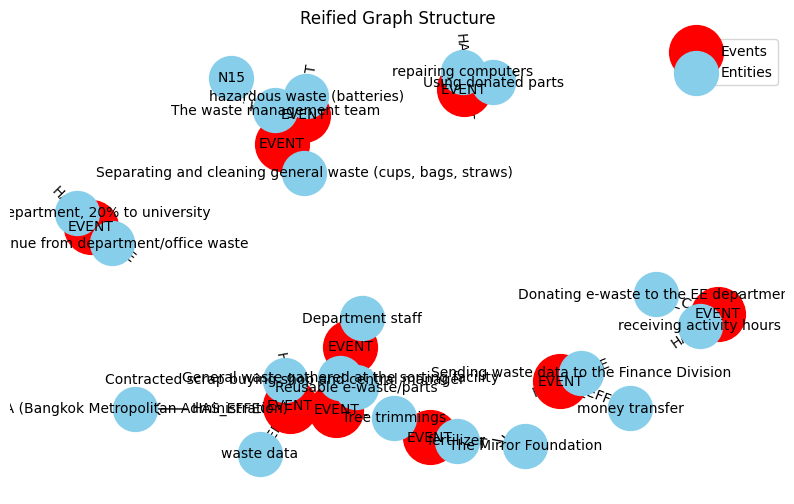

In [55]:
# --- 3. RETRIEVAL SIMULATION (GraphRAG) ---
def query_graph_rag(graph: nx.DiGraph, target_concept: str):
    """
    Scenario: User asks "Why is the garbage overflowing?"
    We find the 'Garbage' node, look for connected Events, and retrieve causes.
    """
    results = []
    
    # Step A: Find the target entity node (Simulating Vector Search)
    target_node_id = target_concept.replace(" ", "_")
    
    # note: this needed to be replaced with vector search
    if not graph.has_node(target_node_id):
        return "Concept not found in graph."

    # Step B: Traverse INCOMING edges to find the Event that caused this
    # (Because we defined Event -> Effect, we look for predecessors)
    predecessors = list(graph.predecessors(target_node_id))
    
    for event_node in predecessors:
        # Check if this is a CausalEvent
        if graph.nodes[event_node].get("type") == "CausalEvent":
            
            event_data = graph.nodes[event_node]
            causes = []
            
            # Step C: From the Event, look for OUTGOING edges that are 'HAS_CAUSE'
            for neighbor in graph.successors(event_node):
                edge_data = graph.get_edge_data(event_node, neighbor)
                if edge_data['role'] == 'HAS_CAUSE':
                    causes.append(graph.nodes[neighbor]['label'])
            
            # Construct the Context Block
            info_block = (
                f"Found Issue: {target_concept}\n"
                f" - Root Causes identified: {', '.join(causes)}\n"
                f" - Original Logic: {event_data['description']}\n"
                f" - Source Evidence: {event_data['source_citation']}..."
            )
            results.append(info_block)
            
    return "\n\n".join(results)

if __name__ == "__main__":
    # --- 4. EXECUTE ---
    # User Query: "Why is garbage overflowing?"
    print(raw_data)
    context = query_graph_rag(G, "garbage")  # Query the object entity

    print("-" * 30)
    print("RETRIEVED CONTEXT FOR LLM:")
    print(context)
    print("-" * 30)
    plot_graph_visual(G)

In [56]:
def inspect_graph_data(G):
    print("\n--- NODE INSPECTION ---")
    for node_id, data in G.nodes(data=True):
        print(f"ID: {node_id}")
        print(f"  Type: {data.get('type')}")
        # Print description if it exists (for Events)
        if 'description' in data:
            print(f"  Logic: {data['description']}")
        print("-" * 10)

    print("\n--- EDGE INSPECTION ---")
    for u, v, data in G.edges(data=True):
        source_label = G.nodes[u].get('label', 'EVENT')
        target_label = G.nodes[v].get('label', 'EVENT')
        print(f"{source_label} --[{data['role']}]--> {target_label}")

# Run it
inspect_graph_data(G)


--- NODE INSPECTION ---
ID: is_sent_to
  Type: CausalEvent
  Logic: is sent to
----------
ID: General_waste_gathered_at_the_sorting_facility
  Type: Entity
----------
ID: BMA_(Bangkok_Metropolitan_Administration)
  Type: Entity
----------
ID: bring_down
  Type: CausalEvent
  Logic: bring down
----------
ID: Department_staff
  Type: Entity
----------
ID: record
  Type: CausalEvent
  Logic: record
----------
ID: Contracted_scrap_buying_shop_and_central_manager
  Type: Entity
----------
ID: waste_data
  Type: Entity
----------
ID: leads_to
  Type: CausalEvent
  Logic: leads to
----------
ID: Sending_waste_data_to_the_Finance_Division
  Type: Entity
----------
ID: money_transfer
  Type: Entity
----------
ID: is_split
  Type: CausalEvent
  Logic: is split
----------
ID: Revenue_from_department/office_waste
  Type: Entity
----------
ID: 80%_to_department,_20%_to_university
  Type: Entity
----------
ID: enables_sending_to
  Type: CausalEvent
  Logic: enables sending to
----------
ID: Separat

In [57]:
from pyvis.network import Network

def plot_interactive(G):
    # Initialize the interactive network
    net = Network(notebook=False, height="750px", width="100%", directed=True)
    
    # Convert networkx graph to pyvis
    net.from_nx(G)
    
    # Tweak physics for better visualization
    net.toggle_physics(True)
    
    # Save and open
    net.show("my_graph.html", notebook=False)

# Run it
plot_interactive(G)

my_graph.html


the graph resulkt show that each fact is isolated because the algorithm use exact match search